# RAGuardian News - A platform to analyze articles from The Guardian using Topic Modelling, Named Entity Recognition, and Retrieval Augmented Generation

Peter de Guzman\
Spring 2026\
IDS 570 - Text as Data\
Professor Astrid Giugni

In [61]:
# packages
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

# Concept

Although keyword search is a standard approach to querying a collection of text documents, this method of search is a fundamentally limited method for identifying documents within a corpus as it relies on uniformity between a searcher's input word and the document's title or metadata. This project addresses the limitations of conventional keyword searches by leveraging three approaches from the field of natural language processing to better support users in retrieving information from a set of documents that is large enough to make manual review impractical. The corpus used for this prototype includes articles from *The Guardian* (a British daily newspaper) published between 4/4/2016-4/4/2026 that mention artificial intelligence.

The three text processing and analytical methods used in this project enable:
1. **Topic Modeling -> Topic Search** - Users can select from a drop-down list of pre-determined topics within the corpus to find related articles. 
2. **Named Entity Recognition -> Entity Search** - Users can submit a name (such as a person, place, or organization) and the platform will return related articles and entities. 
3. **Retrieval Augmented Generation -> Question & Answer** - Users can submit a question using natural language and the platform will find relevant articles and generate a response using locally-hosted open source large language models (LLMs). 




Note: The repository with code for this project can be found using the following link: https://github.com/PeterdeGuzman/RAGuardianNews

# Literature Review

In this section, I will review fundamental developments in the field of natural language processing and recent work related to their application in the development of this prototype. Specific adjustments I made during the iterative process of applying these approaches and the parameters chosen during their implementation are mentioned in their individual sections below. This section contains a brief overview of each method and the reasons they were chosen for this project. 

As a popular unsupervised machine learning method, topic modeling was used to identify themes by clustering the over 24,000 articles in the corpus into groups by theme. An approach based on the use of Bidirectional Encoder Representations from Transformers (BERT), similar to Grootendorst’s BERTopic (Grootendorst, 2022), was chosen which I then extended into a foundation for BERT-based named entity recognition (NER) and the creation of a Facebook AI Similarity Search index for retrieval augmented generation (RAG).

BERT learns contextual representations from unlabelled text data by joining both left and right context. As a result, BERT is more well-suited for understanding the semantic meaning of sentences where the meaning of tokens can change as the sentence progresses, and therefore does not face the same constraints of unidirectional approaches. Latent Dirichlet Allocation (LDA) is an established approach to topic modeling because of its dimensionality reduction capabilities and its efficiency when working with large amounts of text data (Blei et. al, 2003). However, LDA has some clear limitations that are addressed by BERT-based topic models. First, LDA uses a bag-of-words approach, operating under the assumption that all the information needed to create topic clusters is located within the words and that semantic relationships between the words do not need to be retained. BERT-based topic modeling approaches address this by generating document embeddings with transformer-based language models that consider the context of words as members in their full sentences, clustering the embeddings, and then using a class-based TF-IDF approach to create topic representations (Grootendorst, 2022). Second, scholars have found that the instability of LDA topics may lead to errors, and LDA is liable to generate different topics depending on the order of its training data (Mantyla et al., 2018, Agrawal et al., 2018). In a recent experiment comparing LDA and BERT-based topic modeling on medical journal articles, BERTopic produced topics that were more interpretable and semantically coherent (Ma et al., 2025). BERT has also been shown to be competitive with LDA when evaluating both models on topic coherence and topic diversity with a dataset composed of articles from *BBC News* (a comparable source to our corpus of articles from *The Guardian*) (Grootendorst, 2022).

After topic modeling was conducted during the prototype development process, named entity recognition was used to extract entities from the corpus and provide users with the ability to query using specific names for people, organizations, or locations among other entities. A transformer-based architecture was used in this paper to experiment with BERT for stronger NER performance. Previous research has found that bidirectional approaches are useful for named NER, such as the bidirectional long short-term memory networks with Conditional Random Field architecture used by Lample et al. (2016). However, Devlin et al. (2019) found that BERT’s architecture with an additional single layer can achieve a high level of performance for a variety of language-based tasks. In the BERT-based NER case, this final layer is a classification layer that assigns types of entities at the level of individual tokens.

Finally, this prototype incorporates retrieval-augmented generation (RAG) to allow users to query the corpus of *The Guardian* news articles using natural language. In Lewis et al. (2020), the authors introduce how RAG combines both parametric memory (through the use of the large language model) and external retrieval (from the documents in the corpus) to generate more specific language than models that only use parametric data. Two key limitations of using large language models is the tendency for these models to hallucinate (generating responses to user queries that are similar to real answers but nonfactual) and to use outdated information to answer user questions. RAG addresses these limitations by directly retrieving knowledge outside of the data used to train the model (in the case of this prototype, this external knowledge is the text of the articles in the corpus) and using this external knowledge to answer the input query. In this way, RAG-based systems can generate more relevant responses that draw upon current knowledge to answer user questions (Singh et al., 2026). 

# Corpus Preparation and Analysis

For this project, news articles were downloaded from the Guardian API for the time period of `4/4/2016` to `4/4/2026`. The 10 year period was chosen for this pilot project to collect a large number of articles while still avoiding rate limitations when downloading articles through the public API. The 10 year period allowed for the inclusion of articles from before the release of GPT-1 & BERT in 2018, and the widespread adoption of ChatGPT between 2020-2022. The query terms used for the API keyword search were "artificial intelligence", "AI", "generative AI", and "GenAI". These search terms were chosen for this prototype to capture the rise in AI technologies while being more narrow than simply downloading articles related to "technology". Per documentation from *The Guardian* the content endpoint `/search` returns all pieces of content available in the API, while the 'q' query parameter ensures that the API call only returns content that explicitly includes the keyword search term. As I will detail in the "Topic Modeling" section below, this API operates as a sort of a black box, and may introduce unrelated articles into the pipeline. The resulting dataset is 24,660 articles, which was downloaded from the API and saved in a JSON file format. 

**Data Transformation with `dbt`:**
\
\
From the JSON file, articles are loaded into a DuckDB database and saved in the `raw_articles` table. To clean the body text of the articles and prepare them for analysis, the `cleaned_articles.sql` dbt model was written which points to the `raw_articles` table and removes all HTML tags from the body text column before saving it as 'clean_body'. The `DuckDB` database provides the structural foundation of this platform.
\
\
Tests are also implemented with `dbt` to check that all values for id and the body text are unique and not null in the database tables. These tests can be ran by navigating to the `dbt_guardian/` folder and running the `uv run dbt test` command. 



**Descriptive Analysis of the Corpus**

In [62]:
##Corpus Preparation and Analysis
# extract from DuckDB
con = duckdb.connect("guardian_articles.duckdb", read_only=True)
df = con.execute(
    """
    SELECT 
        id, webTitle, webPublicationDate, clean_body
    FROM cleaned_articles
    """
).df()
con.close()

In [63]:
# calculate word count
df["word_count"] = df["clean_body"].str.split().str.len()

summary = pd.DataFrame(
    {
        "Statistic": [
            "Count",
            "Mean",
            "Median",
            "Std. Dev.",
            "Min",
            "25th Percentile",
            "75th Percentile",
            "Max",
        ],
        "Word Count": [
            df["word_count"].count(),
            df["word_count"].mean(),
            df["word_count"].median(),
            df["word_count"].std(),
            df["word_count"].min(),
            df["word_count"].quantile(0.25),
            df["word_count"].quantile(0.75),
            df["word_count"].max(),
        ],
    }
)

summary["Word Count"] = summary["Word Count"].round(2)
summary["Word Count"] = summary["Word Count"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
)
summary["Statistic"] = [
    "Observations",
    "Mean",
    "Median",
    "Standard Deviation",
    "Minimum",
    "25th Percentile",
    "75th Percentile",
    "Maximum",
]

styled = summary.style.format({"Value": "{:,.2f}"}).set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = summary.style.hide(axis="index")
print("Figure 1:")
styled  # print the table

Figure 1:


Statistic,Word Count
Observations,"24,660.00"
Mean,"1,660.29"
Median,909.00
Standard Deviation,"2,649.88"
Minimum,0.00
25th Percentile,648.00
75th Percentile,"1,321.00"
Maximum,"40,783.00"


The 24,660 documents varied in length (measured here in the count of words present in each article). The median documents possessed 909 words, while some some outlier documents were much longer. This distribution is highly right-skewed, and there is much variation in article length. 91% of documents in the corpus were recorded as "article" in *The Guardian* API metadata, while 8% were identified as "liveblog" and the remaining observations represented interactive media or audio pieces. 60% of documents were published under the "News" pillar. 20% were published under "Arts", 9% as "Opinion" pieces, 6% under "Lifestyle" and the remaining 5% were published under the "Sport" pillar. 

Figure 2:


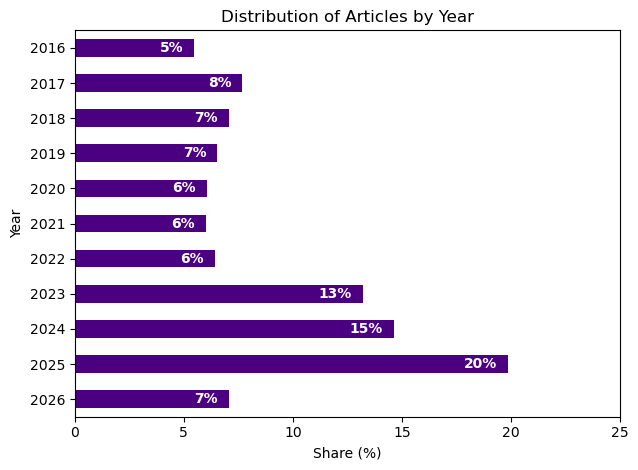

In [64]:
# Distribution of Articles by Year


# plotting number of articles by year
df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(
    kind="barh",
    color="#4B0082",
)
plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, 25)
print("Figure 2:")
plt.show()

 In Figure 2, we observe that there was a steady mention of documents concerning these technologies between 2016-2022 before a sharp increase in 2023 through 2025. This spike in mentions of artificial intelligence was likely due to the November 30, 2022 release of an early demo of ChatGPT by OpenAI (Forbes, 2023). Mentions of artificial intelligence and generative AI remained steady in 2024 before again increasing in 2025. As these terms have become salient topics in modern discussions of the economy, labor, environment, and society it is reasonable to expect that the 2026 number of mentions will be close to or exceed recent years. 

# Topic Modeling

After executing initial descriptive analyses, topic modeling was performed to create dense clusters of articles which I then manually assigned with short topic labels. Once the documents were transformed and loaded into the DuckDB database, the `all-MiniLM-L6-v2` model from the hugging Face `sentence-transformers` Python module was used to create embeddings from the `text` field that was constructed by concatenating the online title and cleaned body text of each article. This model takes in each document and converts it into a dense vector of fixed length (stored in `embeddings.npy`). This model was chosen because it was pretrained and fine-tuned on multiple diverse English-language sources including Reddit, WikiAnswers, WikiHow, and SearchQA which will support the development of the RAG-based Qeustion & Answer functionality of the platform. This model is also lightweight and computationally efficient, making it suitable for prototyping. In addition, the embeddings were normalized, which is a key step required for cosine similarity in Facebook AI Similarity Search (a tool that is used later in the pipeline for the RAG implementation). 


To build the topic model, I defined the following models and parameters: `UMAP`, `HDBSCAN`, `Vectorizer`, `KeyBERTInspired`, and `nr_topics`. The BERT topic model results in embeddings that are 384 dimensions. Uniform Manifold Approximation and Projection (UMAP) and Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN) were used for dimensionality reduction. First, UMAP finds a defined number of nearest neighbors around each defined point and a defined number of target dimensions. For this model, I set the model to use 15 nearest neighbors and 5 target dimensions to create a low-dimensional representation of the data's structure. I also dictated that the sentence transformers measured similarity through cosine similarity, not Euclidean distance. Using cosine similarity here allows neighbors to be found by semantic similarity instead of using the size of the embedding values. 

Then HDBSCAN was used to identify clusters in the low-dimensional space based on density. To prevent clusters that were too small, I set the minimum cluster size at 10 articles. HDBSCAN uses the UMAP output and calculates the Euclidean distance to identify points that are geometrically close in the geometric space created by UMAP. The Excess of Mass or `eom` algorithm defines which level of the hierarchy to select to create each cluster. I chose Excess of Mass because the topics varied in size and density, and a suitable approach needed a balanced way to handle the granularity of topics to prevent splitting large topics while failing to separate topics that were too small. 

The BERT-based topic model runs Class-based Term Frequency-Inverse Document Frequency (c-TF-IDF) over the clustered documents to identify the words that are most distinctive to each topic. c-TF-IDF adapts standard TF-IDF to operate across clusters rather than individual documents. `KeyBERTInspired`, takes advantage of the topics generated by c-TF-IDF and creates a set of documents per topic that are used as the new topic embedding (Grootendorst, 2024). Then, the algorithm re-scores the candidate words by comparing the similarity between their embeddings and the cluster's documents. The `nr_topics` parameter was set to "auto", which computes cosine similarity between the topic embeddings and merges topics that are too close together. Since topic modeling was an exploratory step to analyze this corpus that was then converted into a product offering for users interested in querying articles by topic, I did not force a specific number of final topics. The top ten words are returned to identify each topic cluster. 

I compared different configurations of the topic modeling parameters (see Appendix A.1 for details). The final configuration chosen was one that reduced the share of uncategorized articles while identifying a reasonable number of topics. 

After an initial run of the best-performing BERTopic model, 55 topics were clustered. However, 8,705 uncategorized articles remained, representing approximately 35% of the total articles in the corpus. Upon closer review of the articles included in the "uncategorized" topic, I discovered many articles that referred to "AI" in their titles, suggesting that AI was mentioned among articles with diverse subject matter including education, labor, and art. 

To address the share of articles that were not initially clustered into a topic, I ran the BERT-based topic model for a second time on this subcorpus of articles. Since the model was being run on a smaller collection of uncategorized articles, I adjusted multiple parameters. The minimum cluster size used for HDBSCAN was reduced from 10 articles to 5 articles to account for smaller clusters and the fact that the subcorpus was one-third the size of the main corpus. The minimum number of samples required to do conduct core distance and identify outliers was reduced from 5 to 2. I reduced the minimum number of samples because I determined that the uncategorized topic was too large and after inspecting uncategorized articles I identified several that mentioned artificial intelligence but were being clustered as noise. Finally, the `leaf` selection method was used to identify the finest-grained clusters at the bottom of each hierarchical tree.

This second stage of topic modeling results in 61 topics. However, only 822 total articles in the subcorpus of initially uncategorized articles were clustered into topics. Given the high count of total topics (117) after two stages of topic modeling, I halted the process at this stage before merging the two sets of topic assignments. Since topic modeling results in a name that includes a list of words central to each topic, I finished the process by manually labeling each topic and saving the new topic label assignments in DuckDB. For more details on the full list of topics and corresponding article counts, see Appendix A.2. 

In [65]:
# bring in the labelled topics table
con = duckdb.connect("guardian_articles.duckdb", read_only=True)
df_topics_labelled = con.execute(
    """
    SELECT *
    FROM article_topics_labelled
    """
).df()
con.close()

# topic table after merging and hand-labelling
df_topics_labelled = df_topics_labelled.copy()

df_topics_labelled["source"] = df_topics_labelled["source"].replace(
    {
        "main_model": "First Model",
        "outlier_model": "Subcorpus Model",
        "uncategorised": "Uncategorized",
    }
)

# ── aggregate counts ─────────────────────────────────────────────────────────
topic_table = (
    df_topics_labelled.groupby(["source", "topic_label_clean"])
    .size()
    .reset_index(name="Count")
)

# ── GLOBAL share (NOT per source) ────────────────────────────────────────────
total = topic_table["Count"].sum()

topic_table["Share (%)"] = (topic_table["Count"] / total * 100).round(2)

# ── sort globally by count ───────────────────────────────────────────────────
topic_table = topic_table.sort_values("Count", ascending=False)
topic_table = topic_table.head(20)
topic_table = topic_table.rename(
    columns={
        "source": "Source",
        "topic_label_clean": "Topic",
        "Count": "Count",
        "Share (%)": "Share (%)",
    }
)
# ── formatting for display ────────────────────────────────────────────────────
topic_table["Count"] = topic_table["Count"].apply(lambda x: f"{x:,}")
topic_table["Share (%)"] = topic_table["Share (%)"].astype(str) + "%"

# print(topic_table.to_string(index=False))
styled = topic_table.style.set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = topic_table.style.hide(axis="index")
print("Figure 3:")
styled  # print the table

Figure 3:


Source,Topic,Count,Share (%)
First Model,Government and Politics,"13,766",55.82%
Uncategorized,Uncategorized,"7,883",31.97%
First Model,Football & Soccer,926,3.76%
First Model,Olympics,136,0.55%
First Model,Sleep,110,0.45%
Subcorpus Model,Google Products,106,0.43%
First Model,Christmas Trees,80,0.32%
First Model,Classical Music,47,0.19%
First Model,Formula 1,36,0.15%
First Model,Basketball,34,0.14%


Of the 117 topics, the largest topic is "Government and Politics", created by the initial run of the BERT-based topic model. Accounting for nearly 56% of the total articles in the corpus, this topic represents an outlier. The median number of articles per topic is only 14, and the 75th percentile of articles per topic is 20. The dominant theme suggests that the HDBSCAN cluster, which is density-based, identified "Government and Politics" as a dense cluster and separated it from the remaining topics and the uncategorized group which are low density groupings of articles from the remainder of the diverse corpus. The initial count of 55 topics from the first run of the BERT topic model and the additional 61 topics identified by the BERT topic model ran on the subcorpus of initially uncategorized articles suggests that the topic model struggled to make larger clusters from the more diverse remaining articles that were not overtly related to government and politics. 

Only six clusters included over 100 articles ("Government and Politics", "Uncategorized", "Football & Soccer", "Olympics", "Sleep", and "Google Products"). Reviewing the distribution of articles among the 111 topics with fewer than 100 articles, we note that the two BERT topic models resulted in a large amount of low-density clusters. 95 of these 111 clusters possessed fewer than 25 articles, while 28 possessed fewer than 10 articles. 

Figure 4:


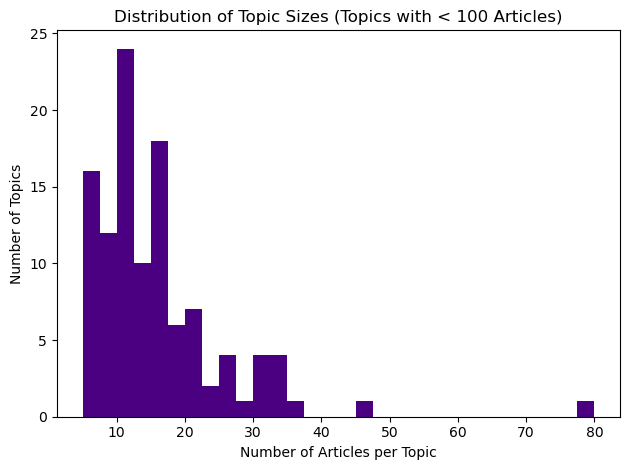

In [66]:
topic_counts = df_topics_labelled["topic_label_clean"].value_counts()

plt.figure()

plt.hist(topic_counts[topic_counts < 100], bins=30, color="#4B0082")

plt.xlabel("Number of Articles per Topic")
plt.ylabel("Number of Topics")
plt.title("Distribution of Topic Sizes (Topics with < 100 Articles)")

plt.tight_layout()
print("Figure 4:")
plt.show()

In [67]:
con = duckdb.connect("guardian_articles.duckdb", read_only=True)
df_maori = con.execute(
    """
    SELECT 
        l.id, l.webTitle, l.webPublicationDate, l.text, l.clean_body, l.topic_id, l.topic_prob, l.topic_label, l.topic_label_clean,
        c.search_terms
    FROM article_topics_labelled l JOIN cleaned_articles c ON l.id = c.id
    WHERE l.topic_label_clean = 'AI and Data Centers'
    """
).df()
con.close()
table = df_maori[
    [
        "topic_label_clean",
        "webTitle",
    ]
].copy()

table = table.rename(
    columns={"topic_label_clean": "Topic", "webTitle": "Article Title"}
)
styled = table.style.hide(axis="index").set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
    ]
)
print("Figure 5:")
styled

Figure 5:


Topic,Article Title
AI and Data Centers,Musk’s xAI wins permit for datacenter’s makeshift power plant despite backlash
AI and Data Centers,Elon Musk’s xAI faces second lawsuit over toxic pollutants from datacenter
AI and Data Centers,"Elon Musk’s xAI datacenter generating extra electricity illegally, regulator rules"
AI and Data Centers,‘Just an unbelievable amount of pollution’: how big a threat is AI to the climate?
AI and Data Centers,Anthropic announces $50bn plan for datacenter construction in US
AI and Data Centers,Elon Musk’s xAI gets permit for methane gas generators
AI and Data Centers,Elon Musk’s xAI accused of pollution over Memphis supercomputer
AI and Data Centers,Elon Musk’s xAI powering its facility in Memphis with ‘illegal’ generators


Few of the final set of topics appeared to specifically center around the concept of artificial intelligence. Of these topics, three were identified: "AI and Data Centers", "Google Products", and "Technology, AI, and Alcohol". After conducting close reading of the articles in the "AI and Data Centers" topic, a clear semantic connection is revealed. Each of these eight articles is related to the controversial construction of datacenters in Memphis, Tennessee by Elon Musk's company xAI to fuel their artificial intelligence products. Although this topic displays a successful case of clustering by the BERT topic model, it was one of the few topics with an explicit connection to the concept of artificial intelligence.


Even after merging in the initially uncategorized articles, the majority of identified topics lacked a clear connection to artificial intelligence. An initial conclusion may be that the BERTopic model struggled to differentiate between the mentions of artificial intelligence within the articles and their other diverse content. However, the content endpoint accessed by the API may also introduce articles that do not explicitly mention the provided search terms (which were "Artificial Intelligence", "AI", "generative AI", and "GenAI" for this prototype.) It may be that the content endpoint returns strict counts based on character or token matching, so any article that contained the letter "a" and "i" together in a word would return a result for the "AI" search term. This is a significant flaw in the design of the content endpoint. I decided to not filter out these articles because I was unable to find clear documentation from *The Guardian* indicating that this was how the endpoint operated. In addition, I was interested in evaluating the BERT-based topic models capacity to identify topics among a diverse corpus of news articles. 

In [68]:
con = duckdb.connect("guardian_articles.duckdb", read_only=True)
df_maori = con.execute(
    """
    SELECT 
        l.id, l.webTitle, l.webPublicationDate, l.text, l.clean_body, l.topic_id, l.topic_prob, l.topic_label, l.topic_label_clean,
        c.search_terms
    FROM article_topics_labelled l JOIN cleaned_articles c ON l.id = c.id
    WHERE l.topic_label_clean = 'Maori Culture and Tattoos'
    """
).df()
con.close()
table = df_maori[["webTitle", "search_terms"]].copy()

table = table.rename(
    columns={"webTitle": "Article Title", "search_terms": "Search Terms"}
)
styled = table.style.hide(axis="index").set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
    ]
)
print("Figure 6:")
styled

Figure 6:


Article Title,Search Terms
Getting a terrible tattoo when you’re young feels like a life lesson – yet so many people still crave more,artificial intelligence
Snapchat removes Māori face tattoo filters after outcry in New Zealand,"AI, generative AI"
"Nōku e whakaora mai ana i tōku reo Māori, i kaha te pā mai o te wawaro e tō ana i a au kia haere ki te moana | Shilo Kino","AI, generative AI"
Jacinda Ardern's speech at Christchurch memorial – full transcript,"AI, generative AI"
Māori moko facial tattoos revived by a new generation with designs on the future,generative AI
"Moana Jackson was the most articulate, original and forceful intellectual of his generation | Morgan Godfrey",generative AI


Upon closer inspection, the smaller topics did indeed cluster articles with similar content, with a few noticeable articles that were slightly different than their within-group peers. Although these articles came in through the data pipeline under the terms "AI", "generative AI", and "artificial intelligence", only one article, "Snapchat removes Māori face tattoo filters after outcry in New Zealand", explicitly mentions artificial intelligence. Upon close reading, this article discusses debates over the addictive nature of tattoos and recent advances in tattoo-related technology. The explicit mention of artificial intelligence occurs in the sentence "Today, there are robot tattoo artists that use artificial intelligence, tattoos done with disappearing ink that manufacturers claim last a year or two, software and apps for better design, temporary face tattoos that supposedly decode brainwaves to measure mental strain, and an increasing demand for laser tattoo removal."

Some of these articles also differed from their peers in terms of focus. Three articles "Getting a terrible tattoo when you’re young feels like a life lesson – yet so many people still crave more", "Snapchat removes Māori face tattoo filters after outcry in New Zealand", "Māori moko facial tattoos revived by a new generation with designs on the future", mentioned tattoos, while the latter two specifically mentioned traditional Māori facial tattoos. One article, "Jacinda Ardern's speech at Christchurch memorial – full transcript" was the transcript of a speech by former Prime Minister of New Zealand in response to the 2019 Christchurch mosque shootings. Another article included in this topic "Nōku e whakaora mai ana i tōku reo Māori, i kaha te pā mai o te wawaro e tō ana i a au kia haere ki te moana | Shilo Kino" is written in te reo Māori by the Māori journalist Shilo Kino. This introduces an interesting example of the BERT-based topic model, which was trained on English corpora, clustering an article in a non-English language. 

The article "Moana Jackson was the most articulate, original and forceful intellectual of his generation | Morgan Godfrey" is an obituary for Moana Jackson, a Māori lawyer and activist, written by the columnist Morgan Godfery. There are two notable errors in the inclusion of this article in the data ingestion pipeline. First, although the article was retrieved from the API search through the search term "generative AI", there is no mention in the obituary of artificial intelligence or generative AI. Instead, it appears that the word "generation" was deemed close enough to the "generative AI" search term to identify this article for retrieval, suggesting the use of a fuzzy matching algorithm in the API search. Ultimately, this sort of keyword search is unhelpful in serving my original intent of retrieving articles from the API related to the concept of artificial intelligence and generative AI. Second, when accessing this website through the online website for *The Guardian*, I noted that the author's true name is "Morgan Godfery", while the `webTitle` parameter returned by the API search instead includes the name "Morgan Godfrey", indicating some errors in the database queried by the API search. 

It is possible that if the parameters for dimensionality reduction (UMAP) and clustering (HDBSCAN) were adjusted, then the topics derived from the BERT topic models would be even more well-separated. Further topic modeling was not conducted because of its computational intensity and timeline constraints. For a future iteration of the topic search platform, a smaller maximum count of topics could be prescribed during the modeling process to limit the clustering of a large amount of low-density topics. Finally, addiional adjustments could be made to the method of topic modeling used on the corpus to balance the inherent tradeoff between coverage and topic count. 

## Demonstration of Topic Search Functionality

In Figures 7 and 8 below, the results of a search of articles in the topic "AI and Data Centers" is displayed. Users are able to choose from the 117 topics and retrieve a set of 5, 10, 20, or 50 articles. The articles are returned in order of most recently published to the oldest publication date within the topic. Each record includes the article's title, publication date, ID, and the cleaned body text of the article. By expanding the drop-down pane of the respective article, users can read the article's text directly. 

Figure 7:

![Topic Search 1](images/TopicSearch_1.png)

Figure 8:

![Topic Search 2](images/TopicSearch_2.png)

# Named Entity Recognition

Named entity recognition was applied to the full corpus of *The Guardian* articles to construct a core piece of the platform's search functionality. Although similar to a standard keyword search, named entity search facilitates a richer search experience because when a user searches the platform for a certain named entity, articles mentioning other closely related entities are also retrieved. While developing this prototype, two NER models were tested. The results of both models are utilized in the user interface of the platform to maximize the coverage of entities within the corpus, allowing users to test the differences between both models and maximizing the platform's likelihood to retrieve articles that are relevant to the named entity search query.

 The first model I tested for named entity recognition is the spaCy package's `en_core_web_lg`. I will refer to this as the "spaCy NER" model. The spaCy NER model was ran on the full corpus. First, the model splits each article's text into tokens. Then tokens are matched to a 300-dimensional static GloVe vector, which are vector representations of words that possess semantic meaning. Once this is complete, Tok2Vec/CNN is used to produce contextualized representations from the token vectors. Every GloVe vector that passes through this CNN is updated using tokens within a small fixed window. This is required because spaCy's Named Entity Recognition algorithm needs a more rich representation of each token beyond the GloVe vector. Finally, the Tok2Vec representations with context are input into spaCy's NER algorithm that reads the sequence of tokens from left-to-right and decides whether each token belongs to a named entity (Explosion AI, 2024).

The spaCy NER model identifies a large set of entities, including 'ORG' (organizations), 'DATE', 'PERSON', 'EVENT', 'NORP' (nationalities, religious or political groups), 'CARDINAL' (numerals that are not 'ORDINAL'), 'FAC' (buildings, airports, highways, or bridges), 'WORK_OF_ART', 'TIME', 'GPE' (geopolitical entities), 'PRODUCT', 'ORDINAL' (such as first or second), 'MONEY', 'LOC' (location), 'PERCENT', 'QUANTITY', 'LAW', and 'LANGUAGE'. One key limitation is that because the Tok2Vec/CNN used in the spaCy NER model relies on a local context window, it can fail to understand the true semantic meaning of entities whose meaning depends on words that are more distant within the sentence. For this reason, I decided to also test a BERT-based model that processes every other token in the sentence simultaneously before deciding whether a certain word belongs to an entity type. 

The BERT-based NER model chosen was a pre-trained BERT Named Entity Recognition model from Hugging Face titled `dslim/bert-base-NER`. This model was chosen because it is relatively lightweight and was trained on entity-annotated news articles, making it suitable for our prototype and news article corpus (Devlin et al., 2018). In this report, I will refer to this as the "BERT NER" model. The BERT NER model is a fine-tuned BERT model with 110M parameters intended for use for named entity recognition tasks. This model was chosen because it is more light-weight than its larger peer model `bert-large-NER` (340M parameters) which was fine-tuned on the same dataset. A faster and lighter version `distilbert-NER` is also available.  

Instead of tokenizing into words like the spaCy NER model, the BERT NER model first tokenizes the text using WordPiece tokenization which splits words into subword units. The WordPiece tokenizer has a 512 token limit, so I sliced each article's text to 3,000 characters which should roughly correspond to 512 tokens. Then, each sentence is wrapped with tags indicating the start and beginning of a sentence. After this step, the token embedding, positional embedding, and segment embedding (marking which sentence the token belongs to) are combined into a 768-dimensional vector. The vectors enter the transformer which, in a simplified description, runs the self-attention mechanism twelve times in parallel and computes vectors representations that capture the semantics of each tokens meanings in the context of the entire sentence. This is where the BERT NER model differs from the spaCy NER model, which uses a local context window which can be smaller then the length of a sentence. After passing through additional layers, including non-linear feed forward network layers and the classification head, the highest probability class is selected for each token. Finally, I selected the `aggregation_strategy="simple"` parameter, which merges subword spans to return readable entities. 

In comparison to the spaCY model, the BERT-based NER model finds fewer categories of entities. The four types of identities identified by this BERT-based NER model are 'ORG' (organization), 'PER' (person), and 'LOC' (location), and 'MISC' (miscellaneous, a category for named entities that do not fit into the other types). 

In [78]:
from IPython.display import display, HTML
import duckdb

DB_PATH = "guardian_articles.duckdb"
con = duckdb.connect(DB_PATH)

# --- spaCy ---
df_spacy = (
    con.execute("""
    SELECT entity_text, entity_label, COUNT(*) AS frequency
    FROM article_entities_spacy
    GROUP BY entity_text, entity_label
    ORDER BY frequency DESC
    LIMIT 10
""")
    .df()
    .rename(
        columns={
            "entity_text": "Entity",
            "entity_label": "Type",
            "frequency": "Frequency",
        }
    )
)

# --- BERT ---
df_bert = (
    con.execute("""
    SELECT entity_text, entity_label, COUNT(*) AS frequency
    FROM article_entities_bert
    GROUP BY entity_text, entity_label
    ORDER BY frequency DESC
    LIMIT 10
""")
    .df()
    .rename(
        columns={
            "entity_text": "Entity",
            "entity_label": "Type",
            "frequency": "Frequency",
        }
    )
)

con.close()

TABLE_STYLES = [
    {
        "selector": "table",
        "props": [
            ("border-collapse", "collapse"),
            ("margin", "0 auto"),
            ("font-size", "12pt"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("border-bottom", "1px solid black"),
            ("text-align", "left"),
            ("padding", "6px"),
        ],
    },
    {"selector": "td", "props": [("padding", "6px")]},
]


def make_styled(df):
    return (
        df.style.hide(axis="index")
        .set_table_styles(TABLE_STYLES)
        .format({"Frequency": "{:,}"})
    )


spacy_html = make_styled(df_spacy).to_html()
bert_html = make_styled(df_bert).to_html()

combined = f"""
<div style="display: flex; gap: 60px; justify-content: center; align-items: flex-start;">
    <div>
        <p style="text-align:center; font-weight:bold; font-size:12pt;">spaCy (en_core_web_lg)</p>
        {spacy_html}
    </div>
    <div>
        <p style="text-align:center; font-weight:bold; font-size:12pt;">BERT (dslim/bert-base-NER)</p>
        {bert_html}
    </div>
</div>
"""

print("Figure 9: Top 10 Most Common Named Entities from Both Models")
display(HTML(combined))

Figure 9: Top 10 Most Common Named Entities from Both Models


Entity,Type,Frequency
US,GPE,"65,267"
UK,GPE,"49,784"
BST,ORG,"49,615"
first,ORDINAL,"44,224"
Trump,ORG,"39,233"
one,CARDINAL,"34,706"
AI,ORG,"30,923"
two,CARDINAL,"28,568"
Australia,GPE,"28,415"
today,DATE,"26,088"


The spaCy model was able to identify 471,454 distinct entities. In comparison, The BERT NER model identified 99,412 distinct entities. This is to be expected given that the BERT NER model assigned entity labels to only 4 entity types compared to the 18 entity types used by the spACy NER model. In addition, spaCy was trained on a broader corpus (OntoNotes 5.0) than the `bert-base-NER` model, which was trained on the CoNLL-2003 Shared Task for named entity recognition (Sang et al., 2003). Finally, BERT's bidirectional attention is more conservative than the Tok2Vec/CNN architecture used by spaCy because it uses entire sentence's context to determine whether a specific word is an entity, while the Tok2Vec approach relies more on the local context around the target word and is more likely to tag a word as an entity based on the neighborhood context's observed patterns. Finally, news articles contain many 'DATE', 'ORDINAL', and 'CARDINAL' entities that are completely ignored by the BERT NER model. Notably, "AI" is identified as a top ten most common entity by both NER models. The United States, United Kingdom, and Australia appear as geopolitical entities in the spaCy NER model, and as locations in the BERT NER model.  

After running both the spaCy and BERT models on the full corpus, I identified a 30-article gap. The spaCy model identified at least one entity in 24,657 articles, while the BERT model only identified entities in 24,627 articles. To understand this discrepancy, I queried the specific articles to investigate how their content could be driving this dropoff. These articles included interactive media, opinion pieces, and regular columns that spoke directly to the reader in first person and lacked entities. It appears that the spaCy NER, which was able to identify from a more diverse set of entity types, was able to identify entities within these articles while the BERT NER model failed to identify any entities within these documents' text. 

## Demonstration of Entity Search Functionality

![NER Example 1](images/NER_Example1.png)

An example of named entity search on the RAGuardian News platform is displayed above. Users are able to toggle between viewing the results of the spaCy NER model, the BERT model, or both models. Relevant articles that include the named entity used in the search box are returned in descending order by web publication date. Users are able to use the slider to select the number of articles with named entities that they wish to be retrieved through their search. On the right-hand side of the page, other relevant entities are included along with the respective count of mentions. 

In this example, the user searched the term "Anthropic" and retrieved 10 articles related to the AI corporation. In the related words, spaCy identifies two key individuals related to Anthropic; Australian Prime Minister Anthony Albanese, who is mentioned in *The Guardian* in relation to Australian laws around arficial intelligence and the generation of explicit content, and California district court Judge Rita Lin who presided over a hearing between Anthropic and the U.S. Department of Defense in early 2026. 

Inspecting the related entities closely, BERT identifies "Claude" as both a PER (person) and ORG (organization) entity, while spaCy only identifies "Claude" as a PERSON entity. This introduces a complication in which named entity recognition models may struggle with identifying certain product or company names when people anthropomorphize artificial intelligence models and corporations assign them human-sounding names to normalize their adoption. 

# RAG Implementation

As mentioned in the review of literature on modern natural language processing techniques, retrieval augmented generation (RAG) extends the traditional operations of large language models trained on general text data by supplying a specific base of documents relevant to certain tasks to improve generated outputs without requiring retraining. 

To improve the search functionality of my news article search prototype, I incorporated two open-source large language models. Both models are freely available through the Ollama software and suitable for quick iteration and platform development. The first model, Meta Llama 3.2 3b, is a 3 billion parameter model tuned for following instructions and summarization. (Ollama, 2025) The second model, Mistral 7B, was developed by Mistral AI and released for public use in 2023. Mistral 7B is a 7.3 billion parameter model that has been praised by some users for its performance in comparison to the Llama 2 class of models and its performance on a general set of English language tasks. (E2E Networks Content Team, 2023). 


Initializing the infrastructure for RAG within this search platform involved several steps. While creating the sentence embeddings in the `embed.py` script of the BERT-based topic modeling pipeline, I normalized the embeddings to prepare for this implementation of RAG. Using the normalized embeddings, I built a FAISS index over these vectors. Using `IndexFlatIP`, I calculated inner product similarity. With normalized vectors, the inner product or dot product is equivalent to cosine similarity. The most similar vectors to the query vector are the vectors with the highest dot product with the query vector (Douze et al., 2024).

Each time a query is submitted by a user the query is encoded with the `SentenceTransformer` model used to create the initial embeddings and normalized. The FAISS index is then searched using the query's vector embedding and *k* articles are returned. For this prototype, I limited *k* to 5 as many of the smaller topics mentioned in the corpus only have 5 articles and I wanted to retrieve the maximum amount of articles that may be more closely related to a certain query's semantic meaning. The FAISS indices are mapped to the retrieved article's IDs, and each article's title, publication date, topic label, and full text are pulled from the related DuckDB table. Finally, the articles are presented to the user with their similarity scores and a side-by-side display of the responses from each model. 

The following prompt template was used:

```
PROMPT_TEMPLATE = """You are a helpful assistant answering questions about The Guardian newspaper articles.
    Use ONLY the follow article excerpts to answer the question.
    If the articles do not contain enough information to answer, say so clearly.

    ARTICLES:
    {context}

    Question: {question}

    ANSWER:"""
```

Both models received identical context. This prevents confounding because both models are not retrieving independently – therefore we are able to compare generation quality but are not directly comparing retrieval quality. Comparisons of generated responses from both models are displayed in the following section. 




## Demonstration of Question & Answer Functionality

**Example 1:**

**Prompt Text:** "What is Elon Musk doing with artificial intelligence?"

First, I tested a possible user question that was directly related to the concept of artificial intelligence. Five articles are returned, sorted in order of similarity score (greatest to least). 

![RAG Example 1](images/RAG_Example1.png)

LLama 3.2 3B replies with a bulleted list of several items mentioned by the five articles related to artificial intelligence and provides a one-sentence summary.

Mistral 7B returns a neat paragraph response and a final sentence acknowledging some limitations in its response, clearly drawing on the last sentence of the system's prompt template. There is a heavy overlap in the specific words and entities mentioned by both prompts. 

**Example 2:**

**Prompt Text:** "What current artificial intelligence models have been created by companies in the Philippines?"

For the second test, I used a prompt related to the concept of artificial intelligence that intentionally included a question whose answer I knew was not present in the corpus.

![RAG Example 2](images/RAG_Example2.png)

As can be seen from the similarity scores assigned to the five retrieved articles, the articles returned by the FAISS index search are less similar to the user query than in Example 1. Both models were unable to answer the question, but clearly acknowledged their inability to do so, proving they followed the guidelines in the prompt template. 

**Example 3:**

**Prompt Text:** "How many touchdowns did Lamar Jackson score during his 2nd MVP campaign?"

Finally, I tested the Q&A system using a prompt that was unrelated to the central concept of artificial intelligence. 



![RAG Example 3](images/RAG_Example3.png)

The retrieved articles were related to American sports, but three of the five were related to the National Basketball Association and not the sport of American football or the National Football League. In addition, the Llama 3.2 3B model misinterpreted the entity supplied in the user query, instead referencing Kendrick Lamar, an American musician who performed during a recent Super Bowl halftime show. Finally, in the conclusion of the Llama model's response, the model acknowledges its inability to answer the question using knowledge from the retrieved articles. 

Mistral 7B provides a more succinct response, clearly acknowledging that the articles retrieved by the similarity search are insufficient to answer the user's question.

# Conclusion

Overall, this prototype was successful in establishing an ETL pipeline that extracted articles from *The Guardian*, cleaned them and loaded them into a queryable DuckDB database, and performed natural language processing techniques (topic modelling, named entity recognition, and retrieval augmented generation) to support the analysis of this corpus by diverse audiences. The use of topic modeling shed additional light on the diversity of articles related to artificial intelligence while also uncovering flaws in *The Guardian* API keyword search. This prototype falls short in multiple ways (detailed below), but provides a starting point for similar analyses of news-related corpora and the development of open source applications for analyzing text as data. 

The major obstacles encountered during the development of this prototype were timeline constraints and limited financial resources. Due to limited time to iterate on the three methodological approaches (topic modeling, NER, and RAG) unsupervised and self-supervised machine learning approaches were chosen. It is possible that hand-labelling both positive and negative examples of topics and entities before training these models would have resulted in better performance. In addition, a limited set of four search terms were chosen to develop this corpus of articles that mentioned artificial intelligence. In the future, different sets of search terms could be tested and this prototype could be expanded to a broader set of concepts or an entirely different focus.  Another major limitation of this project was the lack of modularity introduced by generating the embeddings through the `all-MiniLM-L6-v2` in the `embed.py` script. It is possible that by testing different embeddings a better performing sentence embedding model could have been chosen. Once these embeddings were created, they were used for all downstream steps, including the named entity recognition and the creation of the FAISS index utilized for the RAG responses. 

There are multiple ways in which this work could be extended in the future. First, the current ETL pipeline is not live, but relies on a manual trigger to pull articles from The Guardian API and load them into the DuckDB instance. In the future, this could be live or triggered weekly or monthly to track trends in The Guardian's coverage of topics related to artificial intelligence. Due to timeline constraints, this app was designed to be deployed through Streamlit using localhost. The app could also be deployed for public use via AWS or a similar cloud provider. This would require potentially non-trivial costs due to the requirements to host the corpus and two LLMs in the cloud. A simple structure could involve uploading the articles directly into a S3 bucket, organizing them in a relational database through AWS Redshift or Amazon RDS, then setting up a series of step or AWS Lambda functions to perform each part of the NLP pipeline. An additional (and potentially simpler) infrastructure step could be to Dockerize this repository and upload the image to Amazon Elastic Container Service to run the Streamlit app through AWS Apprunner. 

Finally, alternative models or analytical methods could be implemented at each step of the analysis to provide comparisons to the methods presented above. Latent Dirichlet Allocation, a commonly used topic modeling technique, could be ran to compare to the spaCy Tok2Vec/CNN architecture and the BERT-based NER approach. Many different permutations of the spaCy NER and BERT NER models could be tested with different configurations of their parameters to identify the best-performing model to extract entities from the articles within the corpus. Additional evaluation techniques could also supplement these comparisons. While comparing the spaCy NER and BERT NER models, I calculated agreement between the two models and their Jaccard similarity. Since the models are so different in their count of entity types and approach, the resulting metrics were unhelpful. A more comparable set of models and evaluation metrics could be implemented in the future to test the implementation of named entity recognition on a corpus of news articles. 

Multiple adjustments could be made in the future to improve the efficacy of the RAG Question & Answer system. With more time, I could systematically test different prompts, or support the user in a set of starting prompts. The `top_k` parameter could also be increased to allow the large language model to use a larger number of articles in its context window, potentially providing the model with a larger knowledge base from which to generate an answer. In future iterations, different models could be tested that have been fine-tuned on articles from *The Guardian* or a related set of corpora. In addition, this prototype was developed to run with two local large language models (Ollama 3.2 3B and Mistral 7B). In the future, the app could employ additional open source model or state-of-the-art models available through the purchase of tokens such as Claude, ChatGPT, and Gemini.  Since the models were locally-hosted and ran on a 32GB Mac machine, they could take up to 90 seconds to return the generated response from both models. This would be be inconvenient for internet users and could cause frustration. Future implementations should operate with GPU-backed environments that run on faster hardware and parallelize computation to reduce the time between the user submitting a question and receiving a generated answer. 

In the current era, many large search platforms appear to be moving beyond rigid exact match or fuzzy match keyword searches towards large language model-generated summaries and supporting queries written in natural language. Future work could build on the methods presented here by evaluating alternative strategies for processing natural language queries and synthesizing responses from diverse collections of documents.

# Bibliography

<style>
  .apa-ref {
    padding-left: 2em;
    text-indent: -2em;
    line-height: 1.8;
    margin-bottom: 0.5em;
  }
</style>

<p class="apa-ref">Agrawal, A., Fu, W., & Menzies, T. (2018). What is wrong with topic modeling? And how to fix it using search-based software engineering. <em>Information and Software Technology</em>, <em>98</em>, 74–88. https://doi.org/10.1016/j.infsof.2018.02.005</p>

<p class="apa-ref">Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. <em>Journal of Machine Learning Research</em>, <em>3</em>, 993–1022.</p>

<p class="apa-ref">Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. arXiv. https://doi.org/10.48550/arXiv.1810.04805</p>

<p class="apa-ref">Douze, M., Guzhva, A., Deng, C., Johnson, J., Szilvasy, G., Mazaré, P.-E., Lomeli, M., Hosseini, L., & Jégou, H. (2024). The Faiss library. arXiv. https://doi.org/10.48550/arXiv.2401.08281</p>

<p class="apa-ref">E2E Networks Content Team. (2023, November 6). Mistral 7B vs Llama2: Which performs better and why? <em>E2E Networks</em>. https://www.e2enetworks.com/blog/mistral-7b-vs-llama2-which-performs-better-and-why</p>

<p class="apa-ref">Explosion AI. (n.d.). <em>en_core_web_lg</em> [Trained pipeline]. spaCy Models. https://spacy.io/models/en#en_core_web_lg</p>

<p class="apa-ref">Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. arXiv. https://doi.org/10.48550/arXiv.2203.05794</p>

<p class="apa-ref">Grootendorst, M. (n.d.). Representation models: KeyBERTInspired. <em>BERTopic documentation</em>. https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#custom-model</p>

<p class="apa-ref">Hugging Face. (n.d.). <em>dslim/bert-base-NER</em> [Model card]. https://huggingface.co/dslim/bert-base-NER</p>

<p class="apa-ref">Hugging Face. (n.d.). <em>sentence-transformers/all-MiniLM-L6-v2</em> [Model card]. https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2</p>


<style>
  .apa-ref {
    padding-left: 2em;
    text-indent: -2em;
    line-height: 1.8;
    margin-bottom: 0.5em;
  }
</style>

<p class="apa-ref">Jiang, A. Q., Sablayrolles, A., Mensch, A., Bamford, C., Chaplot, D. S., de las Casas, D., Bressand, F., Lengyel, G., Lample, G., Saulnier, L., Lavaud, L. R., Lachaux, M.-A., Stock, P., Le Scao, T., Lavril, T., Wang, T., Lacroix, T., & El Sayed, W. (2023). Mistral 7B. arXiv. https://doi.org/10.48550/arXiv.2310.06825</p>

<p class="apa-ref">Lample, G., Ballesteros, M., Subramanian, S., Kawakami, K., & Dyer, C. (2016). Neural architectures for named entity recognition. arXiv. https://doi.org/10.48550/arXiv.1603.01360</p>

<p class="apa-ref">Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W., Rocktäschel, T., Riedel, S., & Kiela, D. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. arXiv. https://doi.org/10.48550/arXiv.2005.11401</p>

<p class="apa-ref">Ma, L., Chen, R., Ge, W., Rogers, P., Lyn-Cook, B., Hong, H., Tong, W., Wu, N., & Zou, W. (2025). AI-powered topic modeling: Comparing LDA and BERTopic in analyzing opioid-related cardiovascular risks in women. <em>Experimental Biology and Medicine</em>, <em>250</em>, 10389. https://doi.org/10.3389/ebm.2025.10389</p>

<p class="apa-ref">Mäntylä, M., Claes, M., & Farooq, U. (2018). Measuring LDA topic stability from clusters of replicated runs. arXiv. https://doi.org/10.48550/arXiv.1808.08098</p>

<p class="apa-ref">Marr, B. (2023, May 19). A short history of ChatGPT: How we got to where we are today. <em>Forbes</em>. https://www.forbes.com/sites/bernardmarr/2023/05/19/a-short-history-of-chatgpt-how-we-got-to-where-we-are-today/</p>

<p class="apa-ref">Meta. (2024, September 25). <em>Llama 3.2: 3B</em> [Large language model]. Ollama. https://ollama.com/library/llama3.2:3b</p>

<p class="apa-ref">Sang, E. F. T. K., & De Meulder, F. (2003). Introduction to the CoNLL-2003 shared task: Language-independent named entity recognition. arXiv. https://doi.org/10.48550/arXiv.cs/0306050</p>

<p class="apa-ref">Singh, A., Ehtesham, A., Kumar, S., Talaei Khoei, T., & Vasilakos, A. V. (2025). Agentic retrieval-augmented generation: A survey on agentic RAG. arXiv. https://doi.org/10.48550/arXiv.2501.09136</p>

# Appendix





## A.1 Topic Model Comparison Results



| Version | # Topics | Outliers | Outlier % | Coverage % | Min Cluster Size | Min Samples | n_neighbors | n_components | Method |
|---------|----------|----------|------------|-------------|------------------|-------------|--------------|----------------|---------|
| v2      | 612      | 1303     | 5.28%      | 94.72%      | 5                | 3           | 15           | 5              | eom     |
| v3      | 607      | 1565     | 6.35%      | 93.65%      | 5                | 3           | 25           | 10             | eom     |
| v4      | 651      | 1840     | 7.46%      | 92.54%      | 5                | 3           | 25           | 10             | leaf    |
| v1      | 55       | 6769     | 27.45%     | 72.55%      | 10               | 5           | 15           | 5              | eom     |
| v5      | 24       | 10214    | 41.42%     | 58.58%      | 3                | 2           | 25           | 10             | leaf    |

Note: "v1" was the model configuration selected for the initial topic modeling performed in the first run for this prototype.

## A.2 Full Set of Topics from BERT Topic Modeling

In [72]:
# put full topic table in the appendix
df_topics_labelled = df_topics_labelled.copy()

df_topics_labelled["source"] = df_topics_labelled["source"].replace(
    {
        "main_model": "First Model",
        "outlier_model": "Subcorpus Model",
        "uncategorised": "Uncategorized",
    }
)

# ── aggregate counts ─────────────────────────────────────────────────────────
topic_table = (
    df_topics_labelled.groupby(["source", "topic_label_clean"])
    .size()
    .reset_index(name="Count")
)

# ── GLOBAL share (NOT per source) ────────────────────────────────────────────
total = topic_table["Count"].sum()

topic_table["Share (%)"] = (topic_table["Count"] / total * 100).round(2)

# ── sort globally by count ───────────────────────────────────────────────────
topic_table = topic_table.sort_values("Count", ascending=False)
# topic_table = topic_table.head(20)
topic_table = topic_table.rename(
    columns={
        "source": "Source",
        "topic_label_clean": "Topic",
        "Count": "Count",
        "Share (%)": "Share (%)",
    }
)
# ── formatting for display ────────────────────────────────────────────────────
topic_table["Count"] = topic_table["Count"].apply(lambda x: f"{x:,}")
topic_table["Share (%)"] = topic_table["Share (%)"].astype(str) + "%"

# print(topic_table.to_string(index=False))

styled = topic_table.style.set_table_styles(
    [
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("margin", "0 auto"),
                ("font-size", "12pt"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("border-bottom", "1px solid black"),
                ("text-align", "left"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "right"),
            ],
        },
    ]
)
styled = topic_table.style.hide(axis="index")
styled  # print the table


Source,Topic,Count,Share (%)
First Model,Government and Politics,"13,766",55.82%
Uncategorized,Uncategorized,"7,883",31.97%
First Model,Football & Soccer,926,3.76%
First Model,Olympics,136,0.55%
First Model,Sleep,110,0.45%
Subcorpus Model,Google Products,106,0.43%
First Model,Christmas Trees,80,0.32%
First Model,Classical Music,47,0.19%
First Model,Formula 1,36,0.15%
First Model,Basketball,34,0.14%
